# Credit Risk Model

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc, confusion_matrix)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

In [6]:
df = pd.read_csv('/content/credit_train.csv')

# 2. Display basic info
print("--- Data Info ---")
display(df.head())
print("Shape:", df.shape)
display(df.describe(include='all'))

--- Data Info ---


,age,income,loan_amount,loan_term,credit_score,num_credit_lines,num_delinquencies,employment_years,debt_to_income,home_ownership,loan_purpose,num_inquiries,savings_balance,months_last_delinq,default
0,59,58822,14317,48,669,13,0,0.2,0.122,MORTGAGE,MEDICAL,2,9438.0,NaN,0
1,49,21461,9006,60,612,8,0,2.8,0.443,MORTGAGE,PERSONAL,1,6223.0,NaN,0
2,35,75417,12004,36,724,13,3,8.3,0.152,RENT,DEBT_CONSOLIDATION,2,4063.0,22.0,0
3,63,133964,7904,48,555,11,0,5.6,0.302,OWN,AUTO,4,2957.0,NaN,0
4,28,134306,6135,48,672,10,0,0.1,0.438,MORTGAGE,MEDICAL,5,385.0,NaN,0


Shape: (3000, 15)


,age,income,loan_amount,loan_term,credit_score,num_credit_lines,num_delinquencies,employment_years,debt_to_income,home_ownership,loan_purpose,num_inquiries,savings_balance,months_last_delinq,default
count,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,2867.000000,3000.000000,3000,3000,3000.000000,2853.000000,1487.000000,3000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,5,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MORTGAGE,DEBT_CONSOLIDATION,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1384,1033,NaN,NaN,NaN,NaN
mean,45.105667,59642.316333,17075.790000,37.23600,637.413667,7.441000,1.024667,4.988873,0.281799,NaN,NaN,1.522000,8468.101998,37.191661,0.142000
std,14.061736,39288.988369,13456.259301,14.09775,85.007992,4.032527,1.337655,5.052065,0.132826,NaN,NaN,1.636584,17534.866120,20.333762,0.349108
min,21.000000,7019.000000,996.000000,12.00000,370.000000,1.000000,0.000000,0.000000,0.010000,NaN,NaN,0.000000,48.000000,1.000000,0.000000
25%,33.000000,33366.000000,8339.000000,24.00000,578.000000,4.000000,0.000000,1.400000,0.179000,NaN,NaN,0.000000,1528.000000,20.000000,0.000000
50%,45.000000,49902.500000,13520.000000,36.00000,637.000000,7.000000,0.000000,3.300000,0.273000,NaN,NaN,1.000000,3526.000000,37.000000,0.000000
75%,57.000000,74502.750000,21619.000000,48.00000,697.000000,11.000000,2.000000,6.900000,0.372000,NaN,NaN,2.000000,8876.000000,54.000000,0.000000


In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print("\n--- Missing Values ---")
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))


--- Missing Values ---
                    Missing Count  Missing %
age                             0       0.00
income                          0       0.00
loan_amount                     0       0.00
loan_term                       0       0.00
credit_score                    0       0.00
num_credit_lines                0       0.00
num_delinquencies               0       0.00
employment_years              133       4.43
debt_to_income                  0       0.00
home_ownership                  0       0.00
loan_purpose                    0       0.00
num_inquiries                   0       0.00
savings_balance               147       4.90
months_last_delinq           1513      50.43
default                         0       0.00


In [8]:
# 4. Show dtypes
print("\n--- Data Types ---")
print(df.dtypes)

# 5. Drop NaN in target and reset index
df = df.dropna(subset=['default']).reset_index(drop=True)


--- Data Types ---
age                     int64
income                  int64
loan_amount             int64
loan_term               int64
credit_score            int64
num_credit_lines        int64
num_delinquencies       int64
employment_years      float64
debt_to_income        float64
home_ownership         object
loan_purpose           object
num_inquiries           int64
savings_balance       float64
months_last_delinq    float64
default                 int64
dtype: object


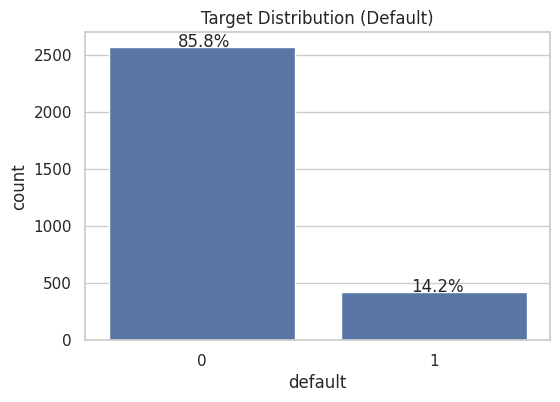

In [9]:
# 6. Target distribution plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='default')
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_y() + p.get_height()
    ax.annotate(percentage, (x, y), size=12)
plt.title('Target Distribution (Default)')
plt.show()

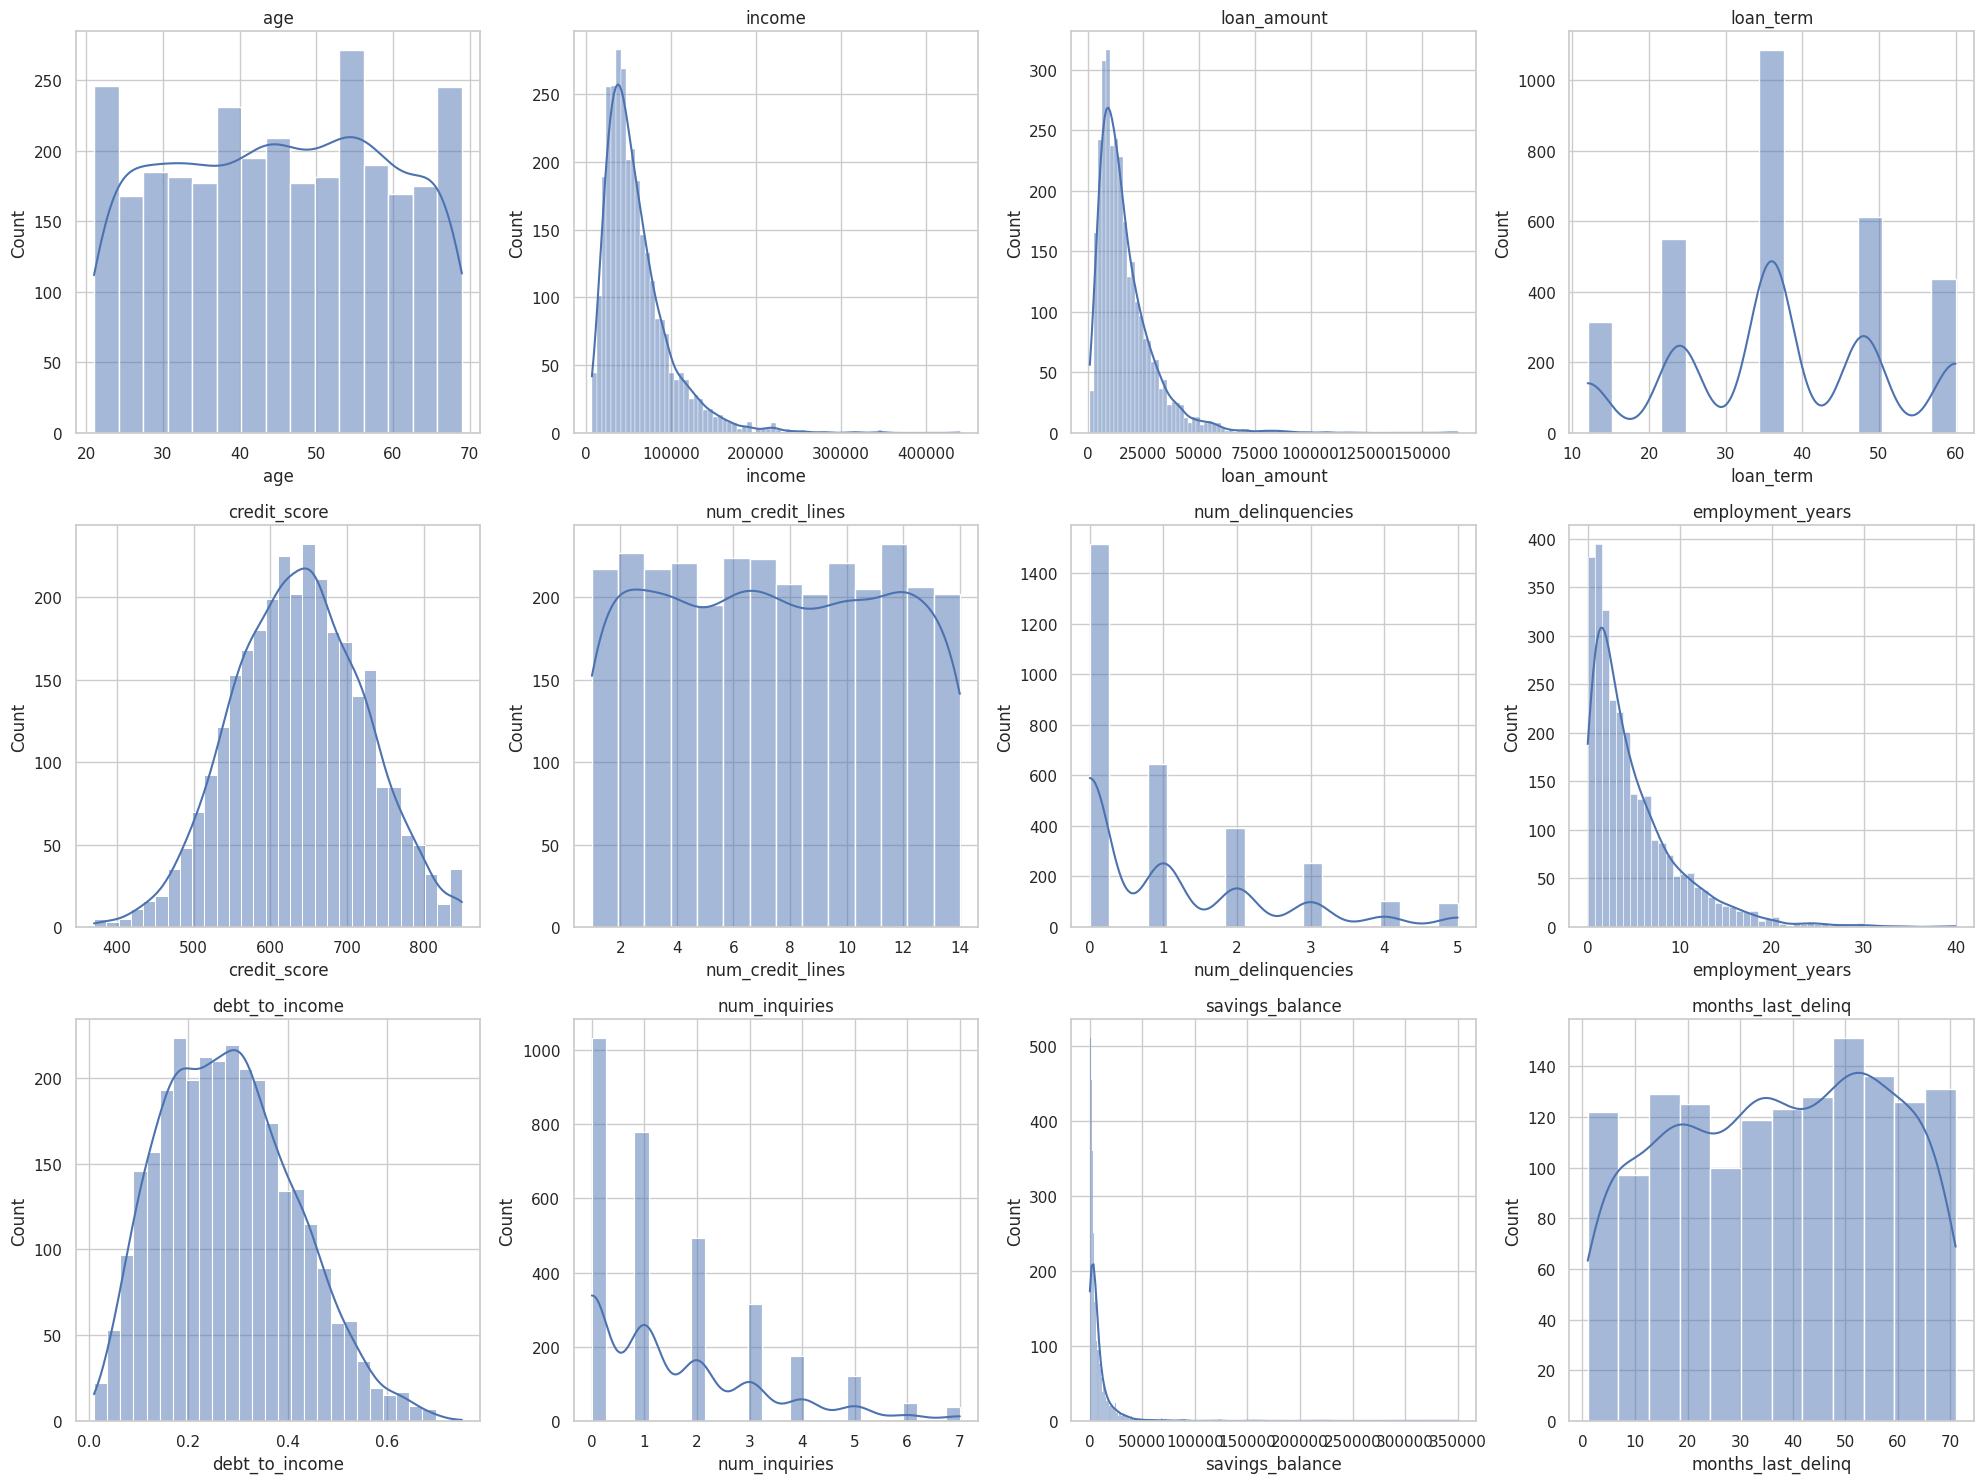

In [10]:
# 7. Histograms for numeric features
num_cols = df.select_dtypes(include='number').columns.drop('default', errors='ignore')
fig, axes = plt.subplots(int(np.ceil(len(num_cols)/4)), 4, figsize=(20, 15))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), ax=axes[i], kde=True)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

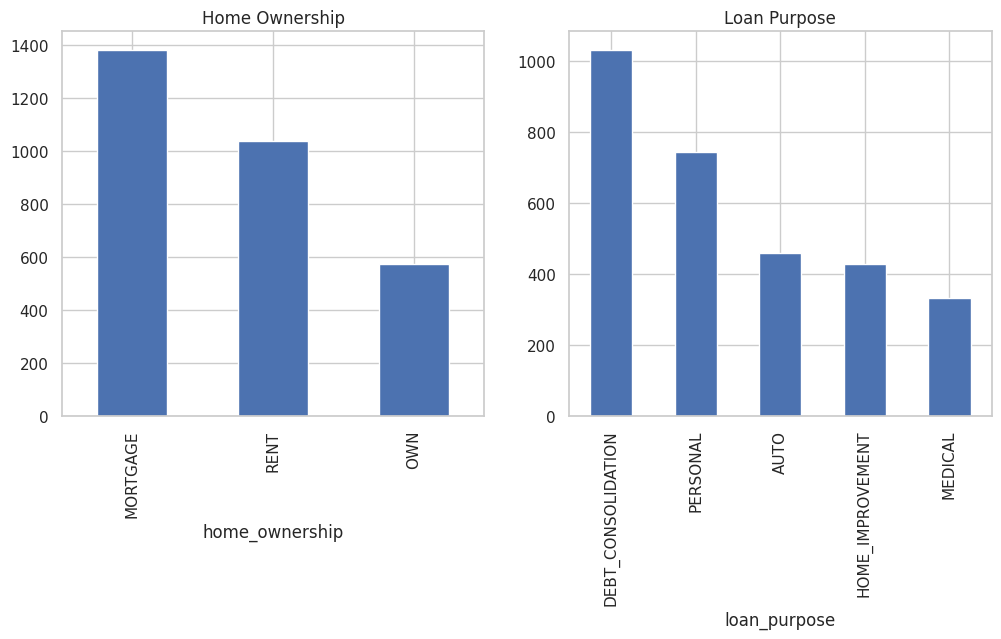

In [11]:
# 8. Bar charts for categorical
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['home_ownership'].value_counts().plot(kind='bar', ax=axes[0], title='Home Ownership')
df['loan_purpose'].value_counts().plot(kind='bar', ax=axes[1], title='Loan Purpose')
plt.show()

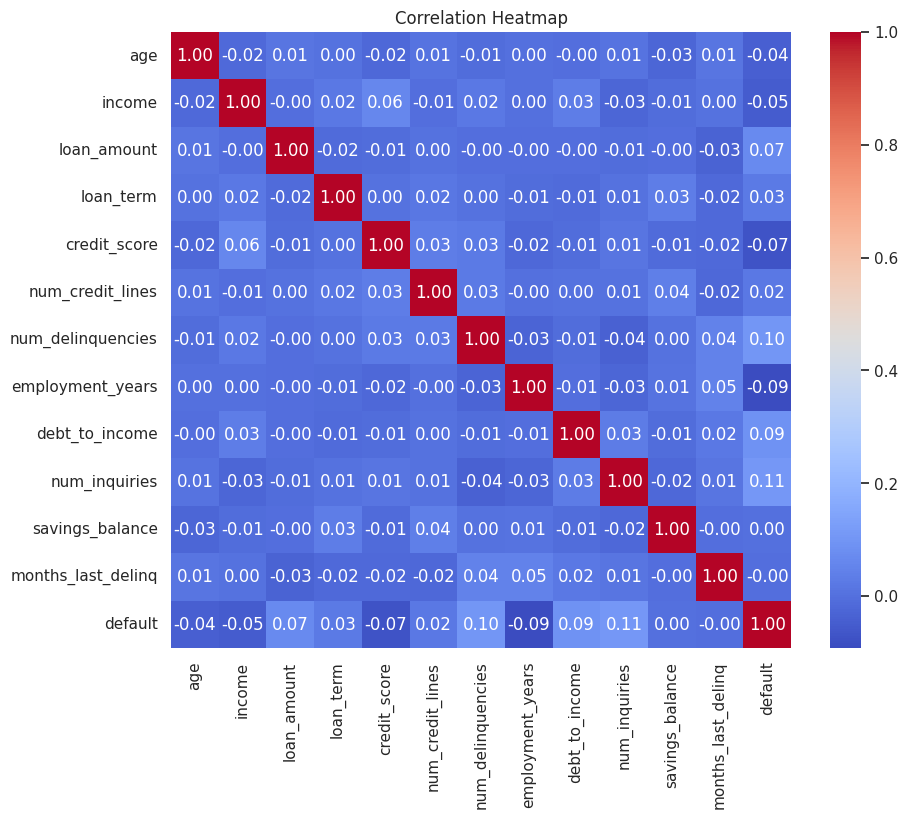

In [12]:
# 9. Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [13]:
# 10. Clean missing values
df['months_last_delinq'] = df['months_last_delinq'].fillna(0)
emp_median = df['employment_years'].median()
sav_median = df['savings_balance'].median()
df['employment_years'] = df['employment_years'].fillna(emp_median)
df['savings_balance'] = df['savings_balance'].fillna(sav_median)
training_medians = {'employment_years': emp_median, 'savings_balance': sav_median}
print('\ntraining_medians saved:', training_medians)


training_medians saved: {'employment_years': 3.3, 'savings_balance': 3526.0}


In [14]:
if df.isnull().sum().sum() != 0:
    nan_cols = df.columns[df.isnull().any()].tolist()
    print("Remaining NaN cols filled with 0:", nan_cols)
    df = df.fillna(0)
assert df.isnull().sum().sum() == 0

In [15]:
# 11. Encode categoricals
df_clean = pd.get_dummies(df, columns=['home_ownership', 'loan_purpose'], drop_first=True, dtype=int)
print("\nNaN count after encoding:", df_clean.isnull().sum().sum())

# 12. Save df_clean
print("df_clean Shape:", df_clean.shape)
print("df_clean Dtypes:\n", df_clean.dtypes)


NaN count after encoding: 0
df_clean Shape: (3000, 19)
df_clean Dtypes:
 age                                  int64
income                               int64
loan_amount                          int64
loan_term                            int64
credit_score                         int64
num_credit_lines                     int64
num_delinquencies                    int64
employment_years                   float64
debt_to_income                     float64
num_inquiries                        int64
savings_balance                    float64
months_last_delinq                 float64
default                              int64
home_ownership_OWN                   int64
home_ownership_RENT                  int64
loan_purpose_DEBT_CONSOLIDATION      int64
loan_purpose_HOME_IMPROVEMENT        int64
loan_purpose_MEDICAL                 int64
loan_purpose_PERSONAL                int64
dtype: object


## step2

In [16]:
# ==========================================
# STEP 2: Feature Engineering and WoE Binning
# ==========================================
# 1. Assert
assert df_clean.isnull().sum().sum() == 0

# 2. New features
df_clean['loan_to_income'] = np.where(df_clean['income'] > 0, df_clean['loan_amount'] / df_clean['income'], 0)
df_clean['payment_to_income'] = np.where((df_clean['loan_term'] > 0) & (df_clean['income'] > 0),
                                         (df_clean['loan_amount'] / df_clean['loan_term']) / df_clean['income'] * 12, 0)
df_clean['credit_utilization_proxy'] = np.where(df_clean['credit_score'] > 0,
                                                df_clean['num_credit_lines'] / (df_clean['credit_score'] / 100), 0)
df_clean['delinq_flag'] = (df_clean['num_delinquencies'] > 0).astype(int)
df_clean['high_inquiry_flag'] = (df_clean['num_inquiries'] >= 3).astype(int)

ratio_cols = ['loan_to_income', 'payment_to_income', 'credit_utilization_proxy']
df_clean[ratio_cols] = df_clean[ratio_cols].replace([np.inf, -np.inf], 0).fillna(0)

In [17]:
# 3. Compute WoE and IV Function
def compute_woe_iv(df, feature, target, bins=5):
    try:
        temp = df[[feature, target]].dropna().copy()
        temp['bin'] = pd.qcut(temp[feature], q=bins, duplicates='drop')
        grouped = temp.groupby('bin', observed=True)[target].agg(['count', 'sum'])
        grouped.columns = ['Total', 'Events']
        grouped['Non_Events'] = grouped['Total'] - grouped['Events']

        total_events = grouped['Events'].sum()
        total_non_events = grouped['Non_Events'].sum()

        grouped['Dist_Events'] = grouped['Events'] / max(total_events, 1)
        grouped['Dist_Non_Events'] = grouped['Non_Events'] / max(total_non_events, 1)

        grouped['WoE'] = np.log((grouped['Dist_Events'] + 1e-9) / (grouped['Dist_Non_Events'] + 1e-9))
        grouped['IV'] = (grouped['Dist_Events'] - grouped['Dist_Non_Events']) * grouped['WoE']

        iv_total = grouped['IV'].sum()
        return grouped, iv_total
    except Exception as e:
        return None, 0.0

# 4. Apply to features
features_to_bin = ['credit_score', 'age', 'income', 'loan_amount', 'debt_to_income',
                   'employment_years', 'savings_balance', 'loan_to_income', 'payment_to_income']

iv_dict = {}
woe_mappings = {}
df_engineered = df_clean.copy()

print("\n--- WoE & IV Tables ---")
for feat in features_to_bin:
    grouped, iv = compute_woe_iv(df_engineered, feat, 'default')
    iv_dict[feat] = iv
    if grouped is not None:
        print(f"\nFeature: {feat} (IV: {iv:.4f})")
        display(grouped[['WoE', 'IV']])

        # 7. Filter IV >= 0.02 and map
        if iv >= 0.02:
            edges = [cat.left for cat in grouped.index.categories] + [grouped.index.categories[-1].right]
            edges[0], edges[-1] = -np.inf, np.inf # catch all out of bounds

            woe_values = grouped['WoE'].tolist()
            woe_mappings[feat] = {'edges': list(edges), 'woe_values': list(woe_values)}

            # Create _woe column
            df_engineered[f"{feat}_woe"] = pd.cut(df_engineered[feat], bins=edges, labels=woe_values, ordered=False)
            df_engineered[f"{feat}_woe"] = pd.to_numeric(df_engineered[f"{feat}_woe"], errors='coerce').fillna(0)
            assert df_engineered[f"{feat}_woe"].isnull().sum() == 0


--- WoE & IV Tables ---

Feature: credit_score (IV: 0.0361)


,WoE,IV
bin,,
"(369.999, 564.0]",0.224568,0.011027
"(564.0, 615.0]",0.134614,0.003821
"(615.0, 658.0]",0.012917,0.000033
"(658.0, 711.0]",-0.118909,0.002714
"(711.0, 850.0]",-0.322736,0.018468



Feature: age (IV: 0.0314)


,WoE,IV
bin,,
"(20.999, 31.0]",0.211001,0.010553
"(31.0, 41.0]",0.099975,0.002054
"(41.0, 50.0]",-0.038351,0.000278
"(50.0, 59.0]",-0.325992,0.018286
"(59.0, 69.0]",-0.037255,0.000269



Feature: income (IV: 0.0177)


...

,WoE,IV
bin,,
"(47.999, 1295.6]",0.024409,0.000120
"(1295.6, 2761.0]",0.062217,0.000793
"(2761.0, 4630.2]",-0.100264,0.001936
"(4630.2, 10452.8]",-0.058678,0.000674
"(10452.8, 350058.0]",0.064176,0.000843



Feature: loan_to_income (IV: 0.0483)


,WoE,IV
bin,,
"(0.008900000000000002, 0.122]",-0.073025,0.001039
"(0.122, 0.21]",-0.361947,0.022974
"(0.21, 0.338]",-0.016513,0.000054
"(0.338, 0.599]",0.037789,0.000289
"(0.599, 9.027]",0.326961,0.023974



Feature: payment_to_income (IV: 0.0283)


,WoE,IV
bin,,
"(0.0018700000000000001, 0.0397]",-0.058678,0.000674
"(0.0397, 0.0709]",-0.225605,0.009382
"(0.0709, 0.12]",-0.116999,0.002625
"(0.12, 0.229]",0.102866,0.002195
"(0.229, 5.919]",0.248180,0.013444


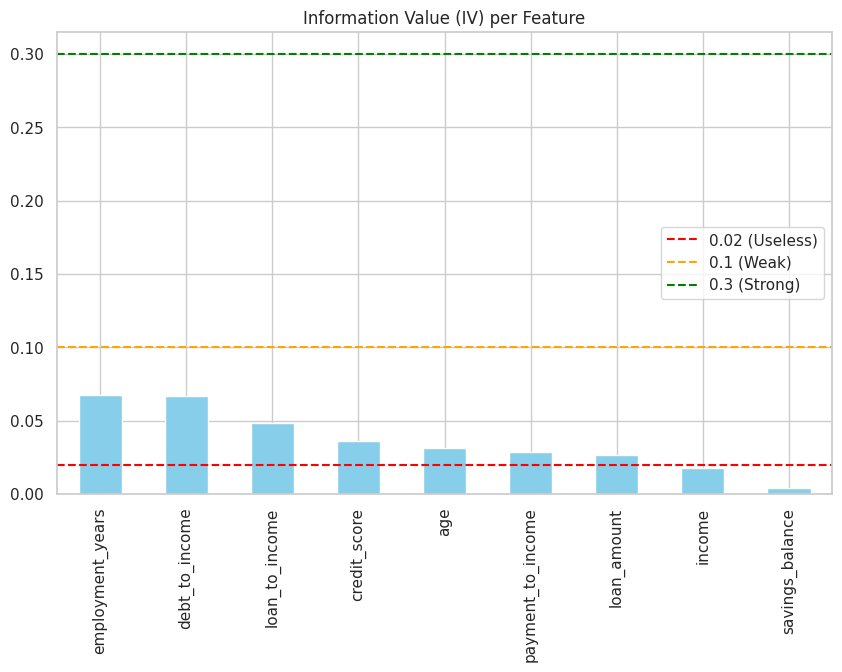

In [18]:
# 6. Bar chart IV
iv_series = pd.Series(iv_dict).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
iv_series.plot(kind='bar', color='skyblue')
plt.axhline(0.02, color='red', linestyle='--', label='0.02 (Useless)')
plt.axhline(0.1, color='orange', linestyle='--', label='0.1 (Weak)')
plt.axhline(0.3, color='green', linestyle='--', label='0.3 (Strong)')
plt.title('Information Value (IV) per Feature')
plt.legend()
plt.show()

In [19]:
# 8. Print final WoE features
final_woe_feats = [col for col in df_engineered.columns if '_woe' in col]
print("\nFinal WoE Features Created:", final_woe_feats)

# 9. Assert zero NaNs
assert df_engineered.isnull().sum().sum() == 0
print("df_engineered missing values:", df_engineered.isnull().sum().sum())


Final WoE Features Created: ['credit_score_woe', 'age_woe', 'loan_amount_woe', 'debt_to_income_woe', 'employment_years_woe', 'loan_to_income_woe', 'payment_to_income_woe']
df_engineered missing values: 0


## step 3


--- Class Distribution BEFORE SMOTE ---
default
0    2059
1     341
Name: count, dtype: int64


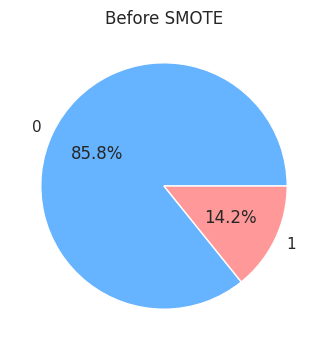


--- Class Distribution AFTER SMOTE ---
default
1    2059
0    2059
Name: count, dtype: int64


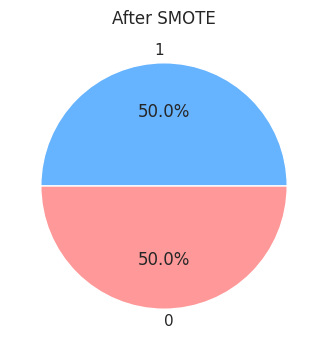

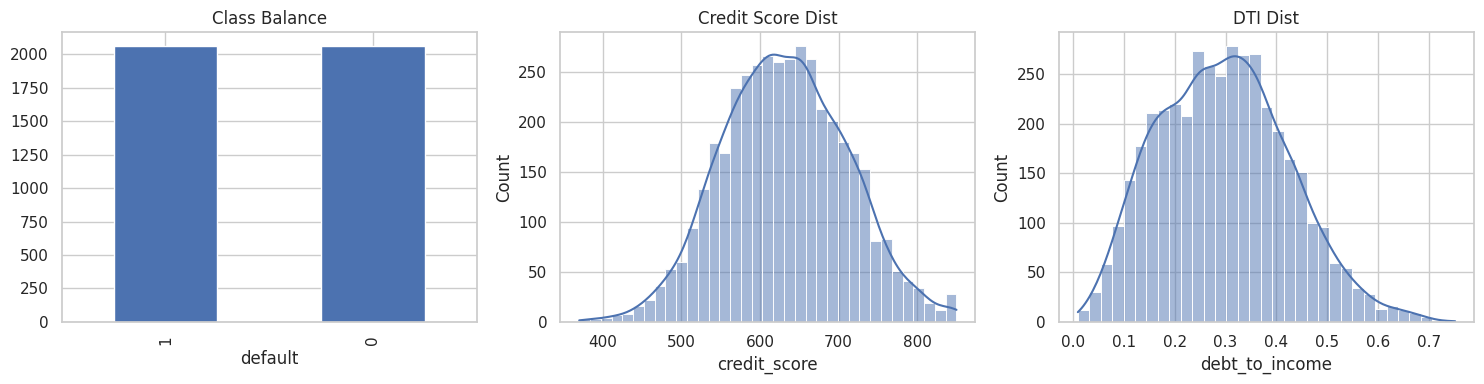


--- Before vs After SMOTE Summary ---
          Metric  Before  After
0  Total Samples    2400   4118
1       Good (0)    2059   2059
2    Default (1)     341   2059


In [20]:
# ==========================================
# STEP 3: Apply SMOTE
# ==========================================
# 1 & 2. Prep X, y
assert df_engineered.isnull().sum().sum() == 0
X = df_engineered.drop(columns=['default']).fillna(0).replace([np.inf, -np.inf], 0)
y = df_engineered['default']
assert X.isnull().sum().sum() == 0

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 4. Class dist BEFORE
print("\n--- Class Distribution BEFORE SMOTE ---")
print(y_train.value_counts())
plt.figure(figsize=(4,4))
y_train.value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title('Before SMOTE')
plt.ylabel('')
plt.show()

# 5 & 6. Apply SMOTE
assert X_train.isnull().sum().sum() == 0
assert not np.any(np.isinf(X_train))
smote = SMOTE(random_state=42, sampling_strategy='auto')
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# 7. Class dist AFTER
print("\n--- Class Distribution AFTER SMOTE ---")
print(y_train_sm.value_counts())
plt.figure(figsize=(4,4))
y_train_sm.value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title('After SMOTE')
plt.ylabel('')
plt.show()

# 8. Side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
y_train_sm.value_counts().plot(kind='bar', ax=axes[0], title='Class Balance')
sns.histplot(X_train_sm['credit_score'], ax=axes[1], kde=True).set_title('Credit Score Dist')
sns.histplot(X_train_sm['debt_to_income'], ax=axes[2], kde=True).set_title('DTI Dist')
plt.tight_layout()
plt.show()

# 9 & 10. Summary and Save
feature_cols = list(X.columns)
print("\n--- Before vs After SMOTE Summary ---")
print(pd.DataFrame({
    'Metric': ['Total Samples', 'Good (0)', 'Default (1)'],
    'Before': [len(y_train), sum(y_train==0), sum(y_train==1)],
    'After': [len(y_train_sm), sum(y_train_sm==0), sum(y_train_sm==1)]
}))

## step4


Lasso Non-zero coefficients: 29 / 30

--- Evaluating Models at Cutoff 0.5 ---


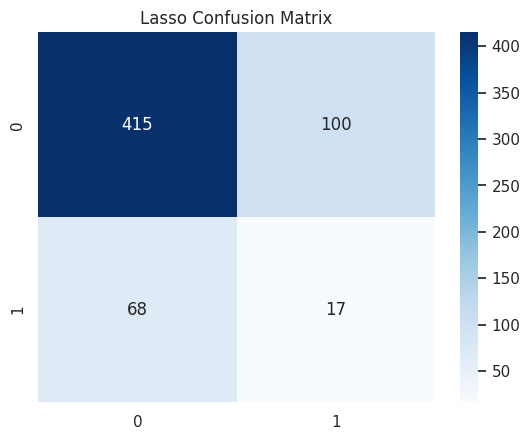

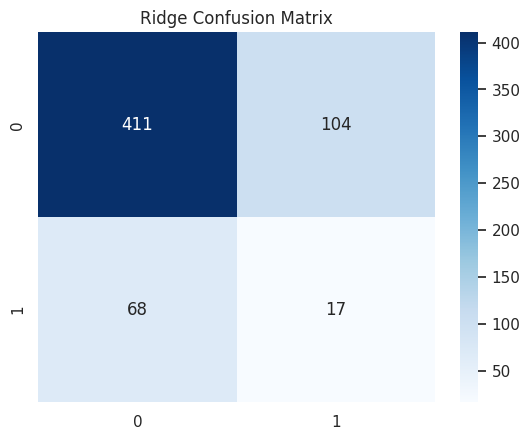

In [21]:
# ==========================================
# STEP 4: Fit Logistic Regression
# ==========================================
# 1. Clean
X_train_sm = pd.DataFrame(X_train_sm, columns=feature_cols).replace([np.inf, -np.inf], 0).fillna(0)
X_test = pd.DataFrame(X_test, columns=feature_cols).replace([np.inf, -np.inf], 0).fillna(0)

# 2. Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)
assert np.isnan(X_train_scaled).sum() == 0

# 3. Lasso
model_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42, max_iter=1000)
model_lasso.fit(X_train_scaled, y_train_sm)
lasso_proba = model_lasso.predict_proba(X_test_scaled)[:, 1]
print(f"\nLasso Non-zero coefficients: {sum(model_lasso.coef_[0] != 0)} / {len(feature_cols)}")

# 4. Ridge
model_ridge = LogisticRegression(penalty='l2', solver='lbfgs', C=1.0, random_state=42, max_iter=1000)
model_ridge.fit(X_train_scaled, y_train_sm)
ridge_proba = model_ridge.predict_proba(X_test_scaled)[:, 1]

# 5. Evaluate at cutoff 0.5
def evaluate_model(y_true, y_prob, name):
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.show()
    return roc_auc, acc, prec, rec, f1

print("\n--- Evaluating Models at Cutoff 0.5 ---")
lasso_metrics = evaluate_model(y_test, lasso_proba, "Lasso")
ridge_metrics = evaluate_model(y_test, ridge_proba, "Ridge")

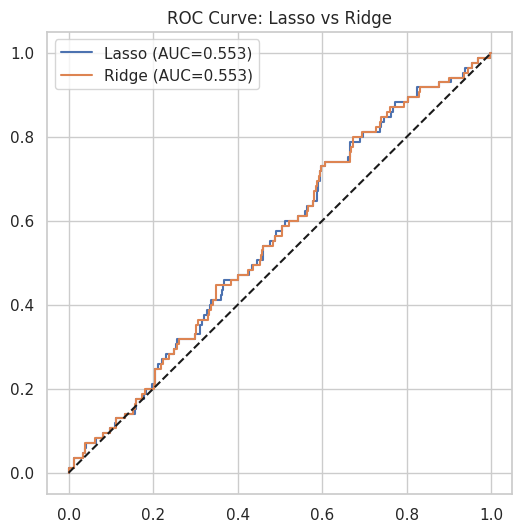

In [22]:
# 6. Plot ROC
fpr_l, tpr_l, _ = roc_curve(y_test, lasso_proba)
fpr_r, tpr_r, _ = roc_curve(y_test, ridge_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr_l, tpr_l, label=f'Lasso (AUC={lasso_metrics[0]:.3f})')
plt.plot(fpr_r, tpr_r, label=f'Ridge (AUC={ridge_metrics[0]:.3f})')
plt.plot([0,1],[0,1], 'k--')
plt.title('ROC Curve: Lasso vs Ridge')
plt.legend()
plt.show()

Model      AUC  Accuracy  Precision  Recall       F1  Non-zero Coefs
Lasso 0.553238  0.720000   0.145299     0.2 0.168317              29
Ridge 0.553238  0.713333   0.140496     0.2 0.165049              30


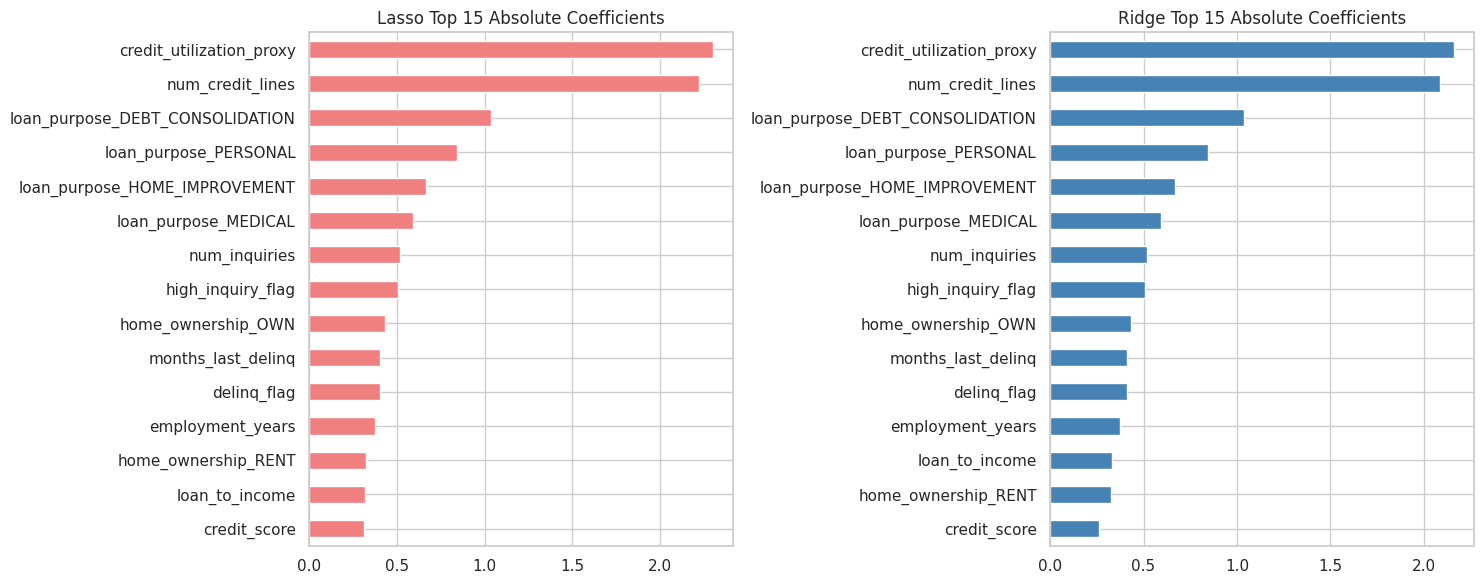

In [23]:
# 7. Print Table
res_df = pd.DataFrame([
    ['Lasso'] + list(lasso_metrics) + [sum(model_lasso.coef_[0] != 0)],
    ['Ridge'] + list(ridge_metrics) + [sum(model_ridge.coef_[0] != 0)]
], columns=['Model', 'AUC', 'Accuracy', 'Precision', 'Recall', 'F1', 'Non-zero Coefs'])
print(res_df.to_string(index=False))

# 8. Plot top 15 features
lasso_coefs = pd.Series(model_lasso.coef_[0], index=feature_cols)
ridge_coefs = pd.Series(model_ridge.coef_[0], index=feature_cols)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
lasso_coefs.abs().sort_values(ascending=False).head(15).plot(kind='barh', ax=axes[0], color='lightcoral')
axes[0].set_title('Lasso Top 15 Absolute Coefficients')
axes[0].invert_yaxis()
ridge_coefs.abs().sort_values(ascending=False).head(15).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Ridge Top 15 Absolute Coefficients')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

## step5: Cross-Validation

Lasso Best C: 0.5, CV AUC: 0.8650
Ridge Best C: 0.5, CV AUC: 0.8656


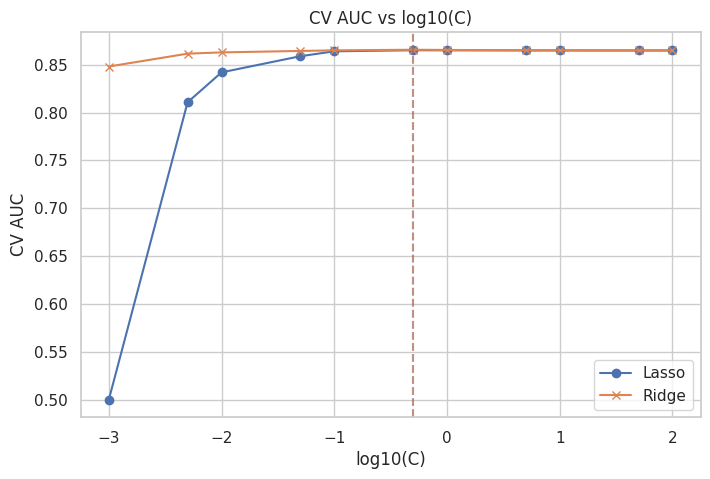

In [24]:
# 1. Assert
assert not np.any(np.isnan(X_train_scaled))

# 2. C Grid
C_grid = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100]

# 3. Lasso CV
cv_lasso = LogisticRegressionCV(penalty='l1', solver='liblinear', Cs=C_grid, cv=5,
                                scoring='roc_auc', random_state=42, max_iter=1000)
cv_lasso.fit(X_train_scaled, y_train_sm)
lasso_mean_auc = cv_lasso.scores_[1].mean(axis=0)
print(f"Lasso Best C: {cv_lasso.C_[0]}, CV AUC: {max(lasso_mean_auc):.4f}")

# 4. Ridge CV
cv_ridge = LogisticRegressionCV(penalty='l2', solver='lbfgs', Cs=C_grid, cv=5,
                                scoring='roc_auc', random_state=42, max_iter=1000)
cv_ridge.fit(X_train_scaled, y_train_sm)
ridge_mean_auc = cv_ridge.scores_[1].mean(axis=0)
print(f"Ridge Best C: {cv_ridge.C_[0]}, CV AUC: {max(ridge_mean_auc):.4f}")

# 5. Plot CV AUC
plt.figure(figsize=(8,5))
plt.plot(np.log10(C_grid), lasso_mean_auc, label='Lasso', marker='o')
plt.plot(np.log10(C_grid), ridge_mean_auc, label='Ridge', marker='x')
plt.axvline(np.log10(cv_lasso.C_[0]), color='blue', linestyle='--', alpha=0.5)
plt.axvline(np.log10(cv_ridge.C_[0]), color='orange', linestyle='--', alpha=0.5)
plt.xlabel('log10(C)')
plt.ylabel('CV AUC')
plt.title('CV AUC vs log10(C)')
plt.legend()
plt.show()

In [25]:
# 6 & 7. Evaluate both best models
model_lasso_best = cv_lasso # already refitted on all data
model_ridge_best = cv_ridge

def eval_best(model, X_t, y_t):
    prob = model.predict_proba(X_t)[:, 1]
    pred = (prob >= 0.5).astype(int)
    return auc(*roc_curve(y_t, prob)[:2]), accuracy_score(y_t, pred), f1_score(y_t, pred, zero_division=0)

lasso_b_auc, lasso_b_acc, lasso_b_f1 = eval_best(model_lasso_best, X_test_scaled, y_test)
ridge_b_auc, ridge_b_acc, ridge_b_f1 = eval_best(model_ridge_best, X_test_scaled, y_test)

# 8. Print CV Summary
print("\n--- Model Evaluation Summary ---")
print(f"Lasso | C=1 AUC: {lasso_metrics[0]:.3f} | Best C: {cv_lasso.C_[0]} | CV AUC: {max(lasso_mean_auc):.3f} | Test AUC: {lasso_b_auc:.3f} | Test F1: {lasso_b_f1:.3f}")
print(f"Ridge | C=1 AUC: {ridge_metrics[0]:.3f} | Best C: {cv_ridge.C_[0]} | CV AUC: {max(ridge_mean_auc):.3f} | Test AUC: {ridge_b_auc:.3f} | Test F1: {ridge_b_f1:.3f}")

# 9. Select Best Model
model_best = model_lasso_best if lasso_b_auc > ridge_b_auc else model_ridge_best
print(f"\n=> Selected Best Model: {'Lasso' if lasso_b_auc > ridge_b_auc else 'Ridge'}")
y_pred_proba = model_best.predict_proba(X_test_scaled)[:,1]
assert not np.any(np.isnan(y_pred_proba))


--- Model Evaluation Summary ---
Lasso | C=1 AUC: 0.553 | Best C: 0.5 | CV AUC: 0.865 | Test AUC: 0.554 | Test F1: 0.169
Ridge | C=1 AUC: 0.553 | Best C: 0.5 | CV AUC: 0.866 | Test AUC: 0.554 | Test F1: 0.181

=> Selected Best Model: Ridge


## step6


Test Class Balance: {0: np.int64(515), 1: np.int64(85)}
KS Value: 0.1355 at Threshold: 0.1529
Best Cutoff (Youden's J): 0.1529


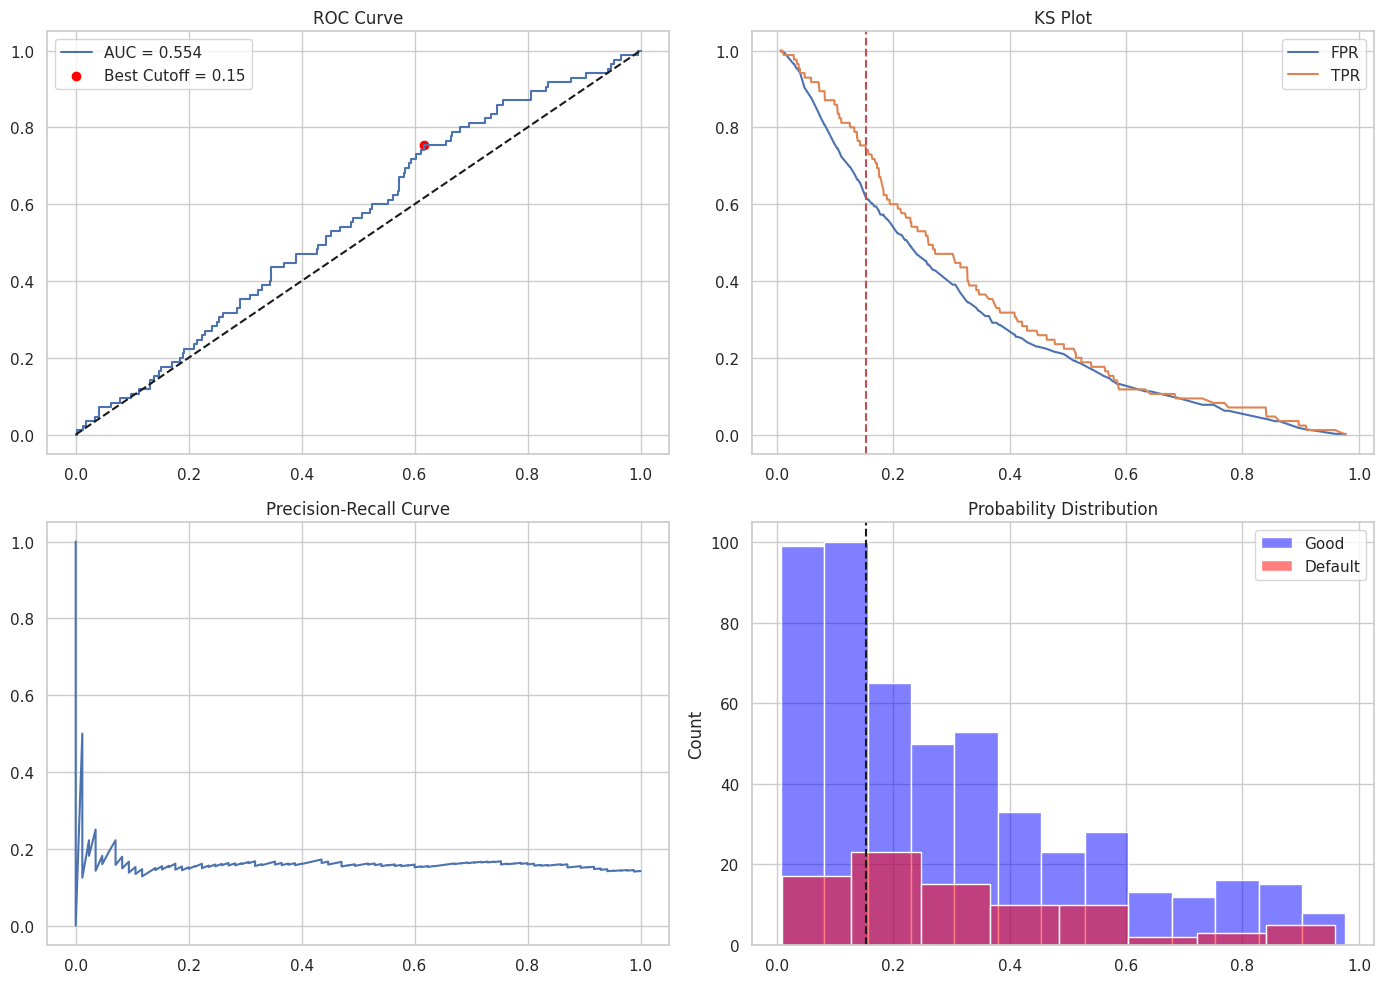


     PERFORMANCE REPORT (Best Cutoff)     
AUC         : 0.5542
Gini        : 0.1084
KS Stat     : 0.1355
Accuracy    : 0.4350
Precision   : 0.1675
Recall (TPR): 0.7529
Specificity : 0.3825
F1-Score    : 0.2741


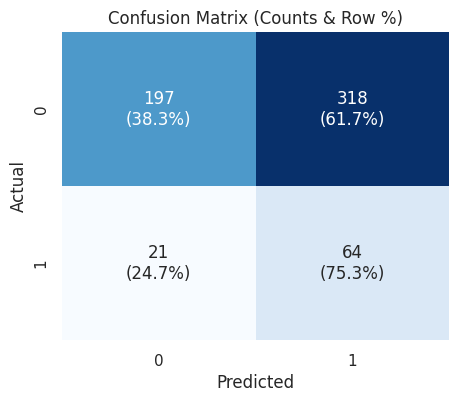

In [27]:
# 1. Assert
assert not np.any(np.isnan(y_pred_proba))
print("\nTest Class Balance:", dict(y_test.value_counts()))

# 2. ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# 3 & 4. KS and Best Cutoff (Youden's J)
ks_stat = max(tpr - fpr)
ks_idx = np.argmax(tpr - fpr)
best_cutoff = thresholds[ks_idx]
print(f"KS Value: {ks_stat:.4f} at Threshold: {best_cutoff:.4f}")
print(f"Best Cutoff (Youden's J): {best_cutoff:.4f}")

# 5. 2x2 Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# a) ROC
axes[0,0].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[0,0].scatter(fpr[ks_idx], tpr[ks_idx], color='red', label=f'Best Cutoff = {best_cutoff:.2f}')
axes[0,0].plot([0,1],[0,1], 'k--')
axes[0,0].set_title('ROC Curve')
axes[0,0].legend()

# b) KS Plot
from sklearn.metrics import precision_recall_curve
# 💡 [FIXED] หั่น Index 0 ออกทั้งหมด เพื่อให้จำนวน Shape ตรงกัน และกราฟไม่เกิน 1.0
axes[0,1].plot(thresholds[1:], fpr[1:], label='FPR')
axes[0,1].plot(thresholds[1:], tpr[1:], label='TPR')
axes[0,1].axvline(best_cutoff, color='r', linestyle='--')
axes[0,1].set_title('KS Plot')
axes[0,1].legend()

# c) PR Curve
prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1,0].plot(rec, prec)
axes[1,0].set_title('Precision-Recall Curve')

# d) Probability Hist
sns.histplot(y_pred_proba[y_test==0], color='blue', alpha=0.5, label='Good', ax=axes[1,1])
sns.histplot(y_pred_proba[y_test==1], color='red', alpha=0.5, label='Default', ax=axes[1,1])
axes[1,1].axvline(best_cutoff, color='k', linestyle='--')
axes[1,1].set_title('Probability Distribution')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# 6. Performance metrics at best cutoff
y_pred_best = (y_pred_proba >= best_cutoff).astype(int)
TN, FP, FN, TP = confusion_matrix(y_test, y_pred_best, labels=[0,1]).ravel()
acc = accuracy_score(y_test, y_pred_best)
prec = precision_score(y_test, y_pred_best, zero_division=0)
rec = recall_score(y_test, y_pred_best, zero_division=0)
spec = TN / max(TN+FP, 1)
f1 = f1_score(y_test, y_pred_best, zero_division=0)
gini = 2 * roc_auc - 1

# 7. Print formatted performance report
print("\n" + "="*40)
print("     PERFORMANCE REPORT (Best Cutoff)     ")
print("="*40)
print(f"AUC         : {roc_auc:.4f}")
print(f"Gini        : {gini:.4f}")
print(f"KS Stat     : {ks_stat:.4f}")
print(f"Accuracy    : {acc:.4f}")
print(f"Precision   : {prec:.4f}")
print(f"Recall (TPR): {rec:.4f}")
print(f"Specificity : {spec:.4f}")
print(f"F1-Score    : {f1:.4f}")
print("="*40)

# 8. Confusion matrix heatmap
cm = np.array([[TN, FP], [FN, TP]])
cm_pct = cm / cm.sum(axis=1)[:, np.newaxis]
annot = np.empty_like(cm).astype(str)
for i in range(2):
    for j in range(2):
        annot[i, j] = f'{cm[i, j]}\n({cm_pct[i, j]:.1%})'

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Counts & Row %)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

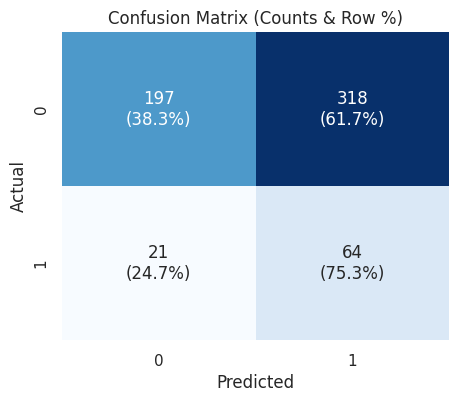

In [28]:
# 8. Confusion Matrix Heatmap
cm = np.array([[TN, FP], [FN, TP]])
cm_pct = cm / cm.sum(axis=1)[:, np.newaxis]
annot = np.empty_like(cm).astype(str)
for i in range(2):
    for j in range(2):
        annot[i, j] = f'{cm[i, j]}\n({cm_pct[i, j]:.1%})'

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Counts & Row %)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## step7


--- Top 5 by Total Profit ---
    Cutoff  Approval_Rate  Default_Rate  Total_Profit  Profit_per_Loan
10    0.15      35.333333      9.905660          -336        -0.560000
11    0.16      37.333333     10.267857          -352        -0.586667
12    0.17      39.000000     10.683761          -392        -0.653333
8     0.13      29.833333      9.497207          -412        -0.686667
9     0.14      32.333333     10.309278          -472        -0.786667


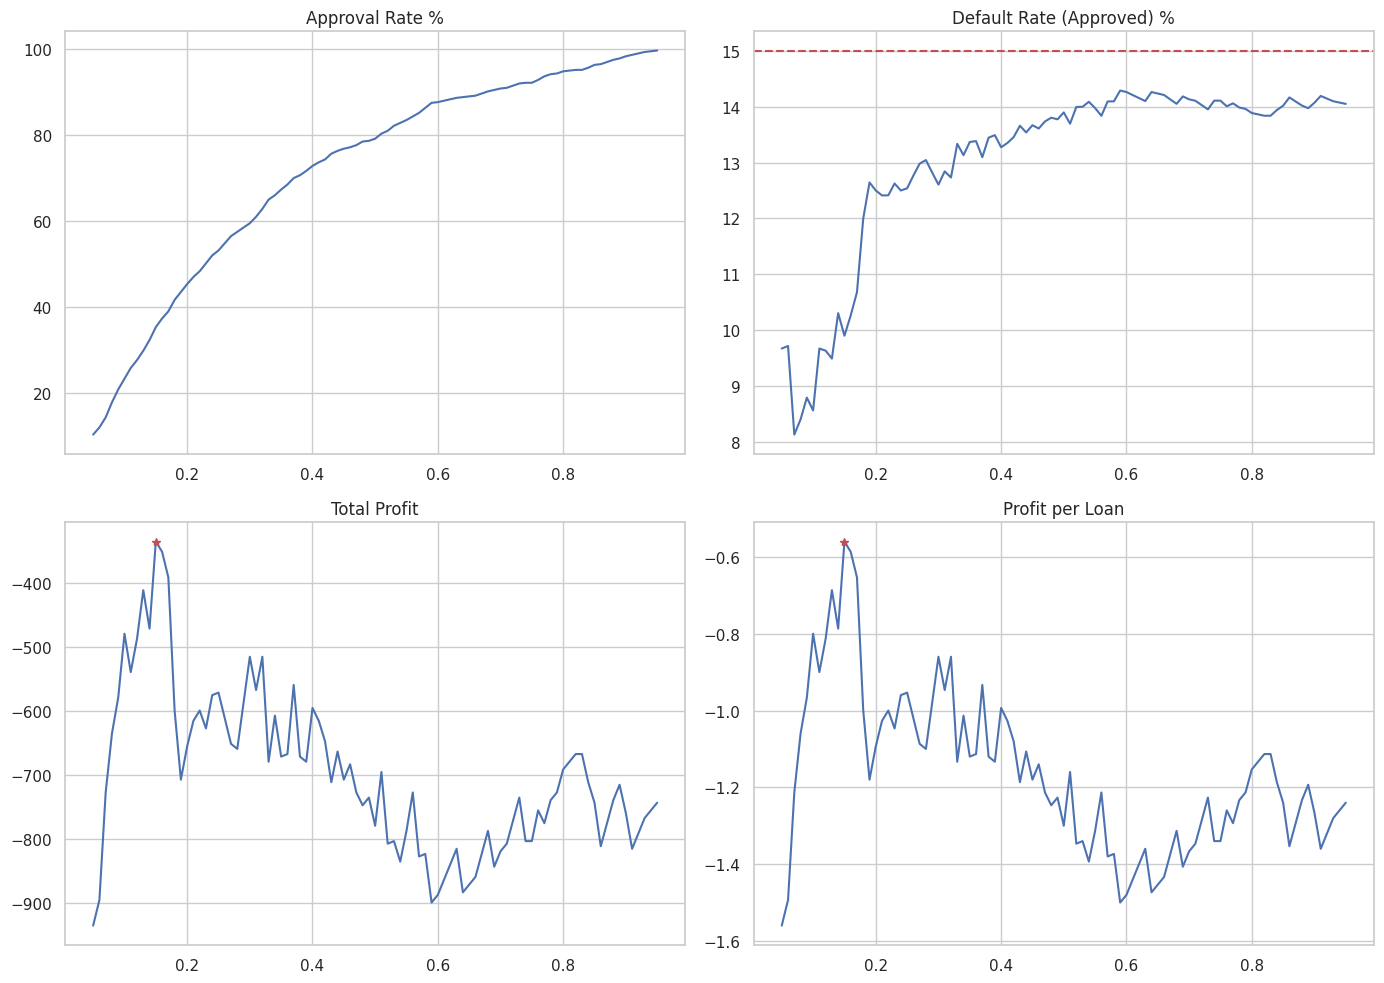

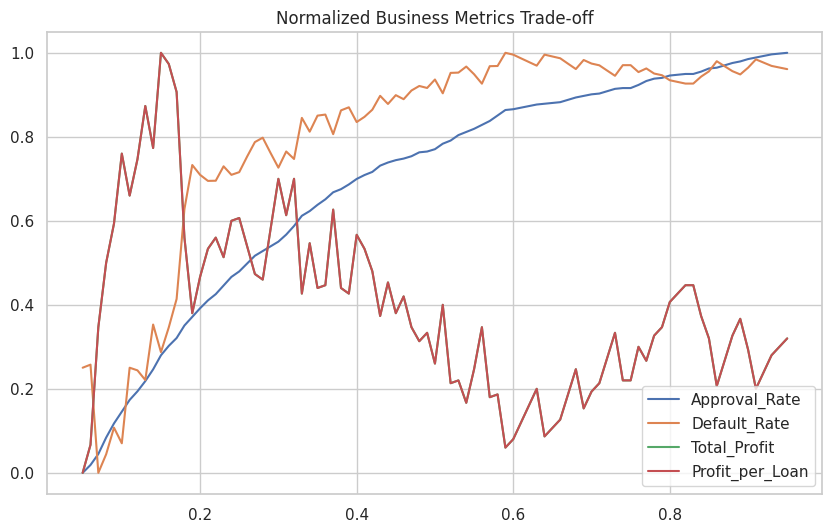


--- Cutoff Summary (0.10 to 0.80) ---
 Cutoff  Approval_Rate  Default_Rate  Total_Profit  Profit_per_Loan
    0.1          23.33          8.57          -480            -0.80
    0.2          45.33         12.50          -656            -1.09
    0.3          59.50         12.61          -516            -0.86
    0.4          72.83         13.27          -596            -0.99
    0.5          79.17         13.89          -780            -1.30
    0.6          87.67         14.26          -888            -1.48
    0.7          90.83         14.13          -820            -1.37
    0.8          94.83         13.88          -692            -1.15

--- Strategy Comparison ---
                     Strategy    Cutoff  Total Profit
0         Best AUC (Youden J)  0.152872          -336
1                  Max Profit  0.150000          -336
2  Max Profit (Default < 15%)  0.150000          -336


In [30]:
# 1. Assert
y_arr = np.array(y_test)
assert len(y_arr) == len(y_pred_proba)

# 2 & 3. Iterate cutoffs
cutoffs = np.arange(0.05, 0.96, 0.01)
results = []

for c in cutoffs:
    pred_c = (y_pred_proba >= c).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_arr, pred_c, labels=[0,1]).ravel()

    appr_rate = (tn + fn) / len(y_arr) * 100
    def_rate_appr = fn / max(tn + fn, 1) * 100
    tot_profit = (tn * 10) + (fn * -70) + ((tp + fp) * -2)
    profit_per_loan = tot_profit / len(y_arr)

    results.append([c, appr_rate, def_rate_appr, tot_profit, profit_per_loan])

# 4. Results DataFrame
res_df = pd.DataFrame(results, columns=['Cutoff', 'Approval_Rate', 'Default_Rate', 'Total_Profit', 'Profit_per_Loan'])
print("\n--- Top 5 by Total Profit ---")
print(res_df.sort_values('Total_Profit', ascending=False).head(5))

# 5. Dashboard
best_profit_idx = res_df['Total_Profit'].idxmax()
best_profit_cutoff = res_df.loc[best_profit_idx, 'Cutoff']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].plot(res_df['Cutoff'], res_df['Approval_Rate']); axes[0,0].set_title('Approval Rate %')
axes[0,1].plot(res_df['Cutoff'], res_df['Default_Rate']); axes[0,1].axhline(15, color='r', linestyle='--'); axes[0,1].set_title('Default Rate (Approved) %')
axes[1,0].plot(res_df['Cutoff'], res_df['Total_Profit']); axes[1,0].plot(best_profit_cutoff, res_df['Total_Profit'].max(), 'r*'); axes[1,0].set_title('Total Profit')
axes[1,1].plot(res_df['Cutoff'], res_df['Profit_per_Loan']); axes[1,1].plot(best_profit_cutoff, res_df['Profit_per_Loan'].max(), 'r*'); axes[1,1].set_title('Profit per Loan')
plt.tight_layout()
plt.show()

# 6. Normalized Trade-off
from sklearn.preprocessing import MinMaxScaler
scaler_minmax = MinMaxScaler()
res_scaled = pd.DataFrame(scaler_minmax.fit_transform(res_df.iloc[:, 1:]), columns=res_df.columns[1:])
res_scaled['Cutoff'] = res_df['Cutoff']

plt.figure(figsize=(10,6))
for col in res_scaled.columns[:-1]:
    plt.plot(res_scaled['Cutoff'], res_scaled[col], label=col)
plt.title('Normalized Business Metrics Trade-off')
plt.legend()
plt.show()

# 7. Table for cutoffs 0.10 - 0.80
print("\n--- Cutoff Summary (0.10 to 0.80) ---")
print(res_df[res_df['Cutoff'].round(2).isin(np.arange(0.1, 0.9, 0.1).round(2))].round(2).to_string(index=False))

# 8. Compare Cutoffs
safe_df = res_df[res_df['Default_Rate'] < 15]
best_safe_cutoff = safe_df.loc[safe_df['Total_Profit'].idxmax(), 'Cutoff'] if not safe_df.empty else best_profit_cutoff

print("\n--- Strategy Comparison ---")
comp_data = {
    'Strategy': ['Best AUC (Youden J)', 'Max Profit', 'Max Profit (Default < 15%)'],
    'Cutoff': [best_cutoff, best_profit_cutoff, best_safe_cutoff],
    'Total Profit': [
        res_df.loc[(res_df['Cutoff'] - best_cutoff).abs().idxmin(), 'Total_Profit'],
        res_df.loc[best_profit_idx, 'Total_Profit'],
        res_df.loc[(res_df['Cutoff'] - best_safe_cutoff).abs().idxmin(), 'Total_Profit']
    ]
}
print(pd.DataFrame(comp_data))